# Exploratory Data Analysis of Top 50 Indian Stocks by Market Capitalization

## Executive Summary

This project presents a cross-sectional exploratory data analysis (EDA) of the top 50 Indian companies ranked by market capitalization. Using a combination of price metrics, return measures, valuation ratios, and technical indicators, the analysis aims to compare large-cap stocks and identify patterns that distinguish stronger performers from relatively weaker ones.

The study focuses on equity screening and comparative analysis rather than direct investment recommendations, providing insights relevant for equity research, fintech analytics, and data-driven decision support.

## Problem Statement & Motivation

Large-cap stocks play a critical role in equity markets due to their size, liquidity, and influence on market indices. Despite being considered relatively stable, large-cap companies can differ significantly in terms of returns, valuation levels, profitability, and technical strength.

Understanding these differences is important for equity research and financial analysis, as investors and analysts often need to compare stocks within the same market-cap category to identify relative strengths, risks, and inefficiencies. This project is motivated by the need to systematically compare large-cap Indian stocks using multiple financial dimensions rather than relying on a single metric.

## Purpose, Use Case & Target Audience

### Purpose
The purpose of this analysis is to demonstrate how cross-sectional equity data can be used to evaluate and compare large-cap stocks across multiple financial dimensions, including performance, valuation, and technical indicators.

### Use Case
The insights from this analysis can be applied to:
- Equity screening and comparative stock analysis
- Identifying relative strengths and weaknesses within large-cap stocks
- Supporting preliminary research for portfolio construction and further investigation

### Target Audience
- Equity research analysts  
- FinTech and data analytics professionals  
- Students and practitioners interested in quantitative equity analysis


## Dataset Description & Feature Overview

The dataset contains cross-sectional information for the top 50 Indian stocks ranked by market capitalization. Each row represents a single stock, while the columns capture a mix of price-based metrics, return measures, valuation ratios, profitability indicators, and technical signals.

To facilitate analysis, the features are grouped into the following categories:

### Price & Market Metrics
- Last Traded Price (LTP)
- Open Price
- Trading Volume
- Market Capitalization

### Return Metrics
- Daily Percentage Change
- 1-Month Returns
- 3-Month Returns
- 1-Year Returns
- 3-Year Returns
- 5-Year Returns

### Valuation Metrics
- Price-to-Earnings (PE) Ratio
- Industry PE Ratio
- Price-to-Book (PB) Ratio
- Earnings Per Share (EPS)
- Dividend

### Profitability & Efficiency Metrics
- Return on Equity (ROE)
- Return on Capital Employed (ROCE)

### Technical Indicators
- 50-Day Moving Average
- 200-Day Moving Average
- Relative Strength Index (RSI)

## Data Loading & Initial Inspection

This section loads the dataset and performs an initial inspection to understand its structure, dimensions, and basic characteristics.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Initial Data Inspection

In [6]:
df = pd.read_csv("Dhan - Top 50 Stocks By Market Cap.csv")

df.head()

,Name,Screener,LTP,Change(%),Open,Volume,Market Cap (Cr.),PE Ratio,Industry PE,52W High,...,PB Ratio,Dividend,ROE,ROCE,EPS,50 DMA,200 DMA,RSI,Margin Funding,Margin Pledge
0,Reliance Industries,https://scanx.trade/company/reliance-industrie...,"1,402.50",-0.15%,"1,410.10","1,57,21,693","18,97,929.29",19.43,10.62,"1,611.80",...,2.17,0.39%,8.54%,8.71%,101.61,"1,525.02","1,436.84",27.79,78.00%,91.00%
1,HDFC Bank,https://scanx.trade/company/hdfc-bank-ltd,918.70,-0.18%,928.00,"4,44,44,755","14,13,381.11",18.28,8.29,"1,020.50",...,2.53,1.19%,13.93%,6.38%,89.49,980.68,976.52,25.25,78.00%,91.00%
2,Bharti Airtel,https://scanx.trade/company/bharti-airtel-ltd,"2,002.20",0.31%,"2,008.80","67,22,567","11,41,675.53",25.47,-0.61,"2,174.50",...,9.67,0.77%,8.11%,18.01%,21.42,"2,090.25","1,954.90",33.77,78.00%,91.00%
3,Tata Consultancy Services,https://scanx.trade/company/tcs-tata-consultan...,"3,150.40",0.89%,"3,150.00","22,69,827","11,39,842.29",23.55,32.23,"4,191.35",...,10.68,4.04%,50.48%,62.02%,131.54,"3,197.87","3,221.46",44.01,78.00%,91.00%
4,State Bank of India,https://scanx.trade/company/state-bank-of-indi...,"1,048.35",1.92%,"1,035.00","1,20,01,641","9,67,691.79",11.32,9.82,"1,052.00",...,1.75,1.50%,15.83%,5.57%,81.94,984.17,865.43,70.87,78.00%,91.00%


In [6]:
df.shape

(50, 26)

In [7]:
df.columns

Index(['Name', 'Screener', 'LTP', 'Change(%)', 'Open', 'Volume',
       'Market Cap (Cr.)', 'PE Ratio', 'Industry PE', '52W High', '52W Low',
       '1M Returns', '3M Returns', '1 Yr Returns', '3 Yr Returns',
       '5 Yr Returns', 'PB Ratio', 'Dividend', 'ROE', 'ROCE', 'EPS', '50 DMA',
       '200 DMA', 'RSI', 'Margin Funding', 'Margin Pledge'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              50 non-null     str    
 1   Screener          50 non-null     str    
 2   LTP               50 non-null     str    
 3   Change(%)         50 non-null     str    
 4   Open              50 non-null     str    
 5   Volume            50 non-null     str    
 6   Market Cap (Cr.)  50 non-null     str    
 7   PE Ratio          50 non-null     str    
 8   Industry PE       50 non-null     float64
 9   52W High          50 non-null     str    
 10  52W Low           50 non-null     str    
 11  1M Returns        50 non-null     str    
 12  3M Returns        50 non-null     str    
 13  1 Yr Returns      50 non-null     str    
 14  3 Yr Returns      50 non-null     str    
 15  5 Yr Returns      50 non-null     str    
 16  PB Ratio          50 non-null     float64
 17  Dividend  

In [9]:
df.describe()

,Industry PE,PB Ratio,RSI
count,50.000000,50.00000,50.000000
mean,12.594400,7.94060,46.854000
std,36.524514,9.08735,12.401904
min,-100.090000,0.83000,16.110000
25%,6.632500,2.60250,38.020000
50%,18.070000,5.05500,44.785000
75%,32.230000,9.49750,57.010000
max,90.210000,55.77000,76.930000


## Data Cleaning & Type Conversion

In [10]:
df.dtypes

Name                    str
Screener                str
LTP                     str
Change(%)               str
Open                    str
Volume                  str
Market Cap (Cr.)        str
PE Ratio                str
Industry PE         float64
52W High                str
52W Low                 str
1M Returns              str
3M Returns              str
1 Yr Returns            str
3 Yr Returns            str
5 Yr Returns            str
PB Ratio            float64
Dividend                str
ROE                     str
ROCE                    str
EPS                     str
50 DMA                  str
200 DMA                 str
RSI                 float64
Margin Funding          str
Margin Pledge           str
dtype: object

### Cleaning Return-Based Columns

In [12]:
percentage_cols = [
    'Change(%)',
    '1M Returns',
    '3M Returns',
    '1 Yr Returns',
    '3 Yr Returns',
    '5 Yr Returns'
]

for col in percentage_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

In [18]:
df.dtypes

Name                    str
Screener                str
LTP                     str
Change(%)           float64
Open                    str
Volume                  str
Market Cap (Cr.)        str
PE Ratio                str
Industry PE         float64
52W High                str
52W Low                 str
1M Returns          float64
3M Returns          float64
1 Yr Returns        float64
3 Yr Returns        float64
5 Yr Returns        float64
PB Ratio            float64
Dividend                str
ROE                     str
ROCE                    str
EPS                     str
50 DMA                  str
200 DMA                 str
RSI                 float64
Margin Funding          str
Margin Pledge           str
dtype: object

### Cleaning Numeric Columns

In [20]:
numeric_cols = [
    'LTP', 'Open', 'Volume', 'Market Cap (Cr.)',
    'PE Ratio', 'Industry PE', '52W High', '52W Low',
    'PB Ratio', 'EPS', '50 DMA', '200 DMA', 'RSI'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )


### Post-Cleaning Data Check

In [21]:
df.dtypes

Name                    str
Screener                str
LTP                 float64
Change(%)           float64
Open                float64
Volume              float64
Market Cap (Cr.)    float64
PE Ratio            float64
Industry PE         float64
52W High            float64
52W Low             float64
1M Returns          float64
3M Returns          float64
1 Yr Returns        float64
3 Yr Returns        float64
5 Yr Returns        float64
PB Ratio            float64
Dividend                str
ROE                     str
ROCE                    str
EPS                 float64
50 DMA              float64
200 DMA             float64
RSI                 float64
Margin Funding          str
Margin Pledge           str
dtype: object

## Univariate Analysis

This section explores the distribution and basic characteristics of individual variables to understand how large-cap stocks differ across key financial and market metrics.


In [24]:
df['Market Cap (Cr.)'].describe()

count    5.000000e+01
mean     4.309421e+05
std      3.471402e+05
min      1.696109e+05
25%      2.414235e+05
50%      2.980841e+05
75%      4.577232e+05
max      1.897929e+06
Name: Market Cap (Cr.), dtype: float64

### Distribution of Market Capitalization

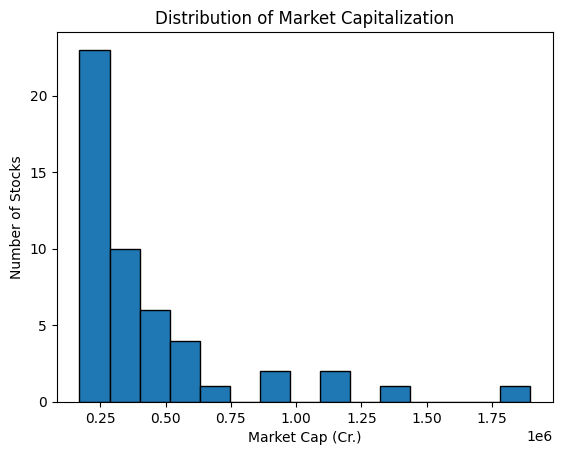

In [30]:
plt.hist(df['Market Cap (Cr.)'], bins=15, edgecolor='black', linewidth=1)
plt.xlabel('Market Cap (Cr.)')
plt.ylabel('Number of Stocks')
plt.title('Distribution of Market Capitalization')
plt.show()

### Distribution of 1-Year Returns

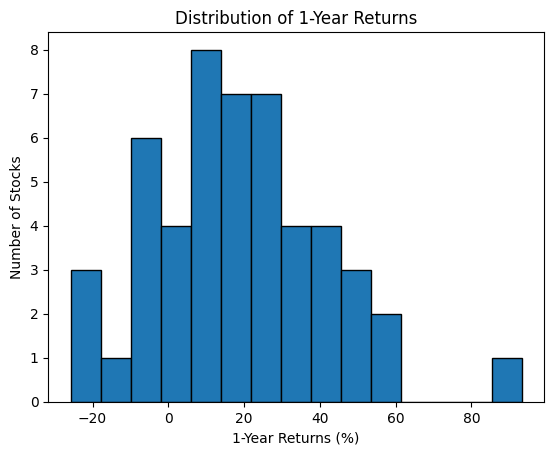

In [29]:
plt.hist(df['1 Yr Returns'], bins=15, edgecolor='black', linewidth=1)
plt.xlabel('1-Year Returns (%)')
plt.ylabel('Number of Stocks')
plt.title('Distribution of 1-Year Returns')
plt.show()

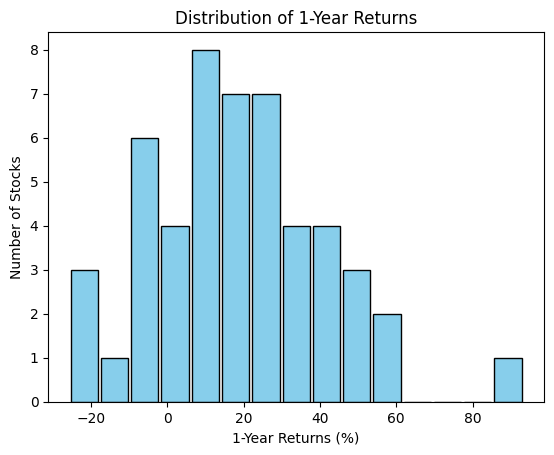

In [36]:
plt.hist(df['1 Yr Returns'],bins=15,rwidth=0.9,edgecolor='black', color='skyblue')
plt.xlabel('1-Year Returns (%)')
plt.ylabel('Number of Stocks')
plt.title('Distribution of 1-Year Returns')
plt.show()

## Risk & Valuation Analysis

This section examines valuation and risk-related metrics to understand how large-cap stocks differ in terms of pricing, market expectations, and relative risk.

In [37]:
df['PE Ratio'].describe()

count      50.000000
mean       60.756000
std       207.507126
min         7.120000
25%        17.350000
50%        26.810000
75%        36.862500
max      1491.580000
Name: PE Ratio, dtype: float64

### Distribution of Price-to-Earnings (PE) Ratios

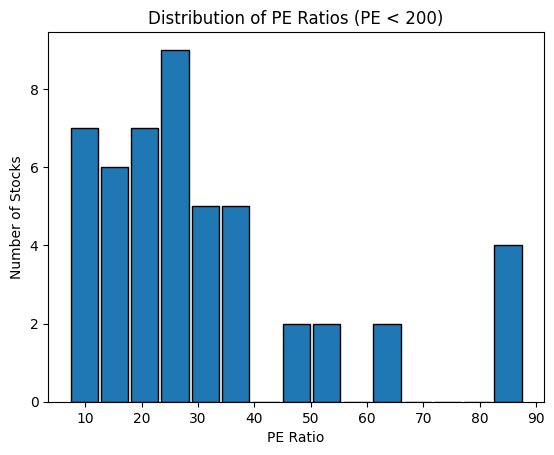

In [40]:
filtered_pe = df[df['PE Ratio'] < 200]['PE Ratio']
plt.hist(filtered_pe, bins=15, rwidth=0.9, edgecolor='black')
plt.xlabel('PE Ratio')
plt.ylabel('Number of Stocks')
plt.title('Distribution of PE Ratios (PE < 200)')
plt.show()

###
After excluding extreme outliers, most large-cap stocks trade within a relatively narrow P/E range, indicating broadly comparable valuation levels across market leaders.

## Data Cleaning & Type Conversion

In [7]:
df.dtypes

Name                    str
Screener                str
LTP                     str
Change(%)               str
Open                    str
Volume                  str
Market Cap (Cr.)        str
PE Ratio                str
Industry PE         float64
52W High                str
52W Low                 str
1M Returns              str
3M Returns              str
1 Yr Returns            str
3 Yr Returns            str
5 Yr Returns            str
PB Ratio            float64
Dividend                str
ROE                     str
ROCE                    str
EPS                     str
50 DMA                  str
200 DMA                 str
RSI                 float64
Margin Funding          str
Margin Pledge           str
dtype: object

### Cleaning Return-Based Columns

In [8]:
return_cols = [
    'Change(%)',
    '1M Returns',
    '3M Returns',
    '1 Yr Returns',
    '3 Yr Returns',
    '5 Yr Returns'
]

for col in return_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )


### Cleaning Numeric Columns

In [9]:
numeric_cols = [
    'LTP', 'Open', 'Volume', 'Market Cap (Cr.)',
    'PE Ratio', 'Industry PE', '52W High', '52W Low',
    'PB Ratio', 'EPS', '50 DMA', '200 DMA', 'RSI'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

### Post-Cleaning Data Check

In [10]:
df.dtypes

Name                    str
Screener                str
LTP                 float64
Change(%)           float64
Open                float64
Volume                int64
Market Cap (Cr.)    float64
PE Ratio            float64
Industry PE         float64
52W High            float64
52W Low             float64
1M Returns          float64
3M Returns          float64
1 Yr Returns        float64
3 Yr Returns        float64
5 Yr Returns        float64
PB Ratio            float64
Dividend                str
ROE                     str
ROCE                    str
EPS                 float64
50 DMA              float64
200 DMA             float64
RSI                 float64
Margin Funding          str
Margin Pledge           str
dtype: object

## Univariate Analysis

### Market Capitalization

In [11]:
df['Market Cap (Cr.)'].describe()

count    5.000000e+01
mean     4.309421e+05
std      3.471402e+05
min      1.696109e+05
25%      2.414235e+05
50%      2.980841e+05
75%      4.577232e+05
max      1.897929e+06
Name: Market Cap (Cr.), dtype: float64

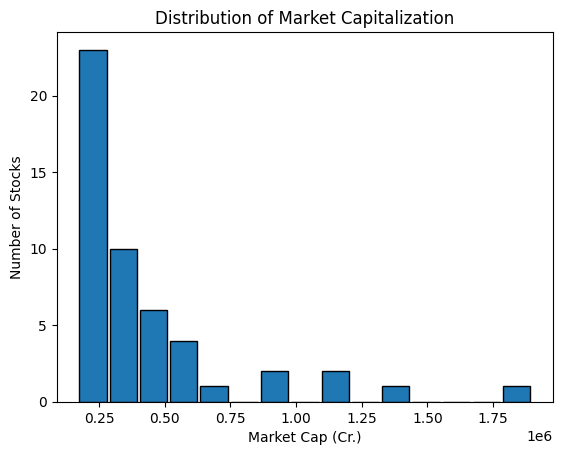

In [13]:
plt.hist(
    df['Market Cap (Cr.)'],
    bins=15,
    rwidth=0.9,
    edgecolor='black'
)
plt.xlabel('Market Cap (Cr.)')
plt.ylabel('Number of Stocks')
plt.title('Distribution of Market Capitalization')
plt.show()

### One-Year Returns

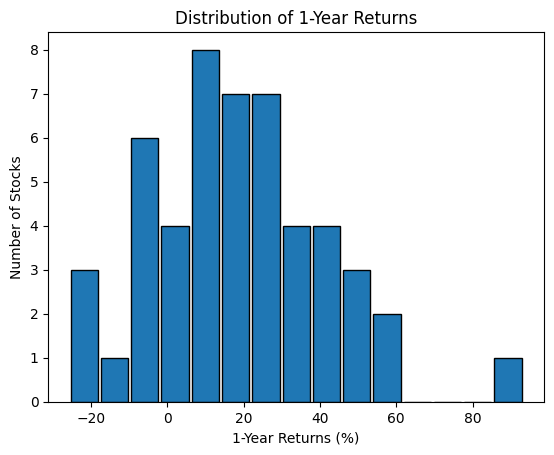

In [14]:
plt.hist(
    df['1 Yr Returns'],
    bins=15,
    rwidth=0.9,
    edgecolor='black'
)
plt.xlabel('1-Year Returns (%)')
plt.ylabel('Number of Stocks')
plt.title('Distribution of 1-Year Returns')
plt.show()

### Price-to-Earnings (PE) Ratio

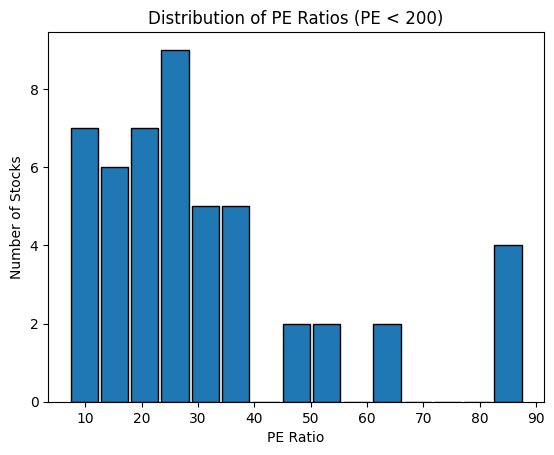

In [15]:
filtered_pe = df[df['PE Ratio'] < 200]['PE Ratio']

plt.hist(
    filtered_pe,
    bins=15,
    rwidth=0.9,
    edgecolor='black'
)
plt.xlabel('PE Ratio')
plt.ylabel('Number of Stocks')
plt.title('Distribution of PE Ratios (PE < 200)')
plt.show()

## Bivariate Analysis

### Valuation vs Performance: PE Ratio and 1-Year Returns

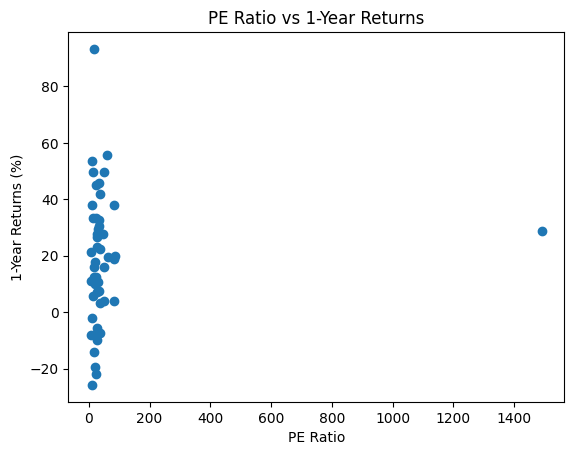

In [16]:
plt.scatter(df['PE Ratio'], df['1 Yr Returns'])
plt.xlabel('PE Ratio')
plt.ylabel('1-Year Returns (%)')
plt.title('PE Ratio vs 1-Year Returns')
plt.show()

**Observation:**  
The scatter plot does not indicate a strong linear relationship between PE ratios and 1-year returns, suggesting that higher valuation alone does not guarantee superior performance among large-cap stocks.

### Market Capitalization vs Performance

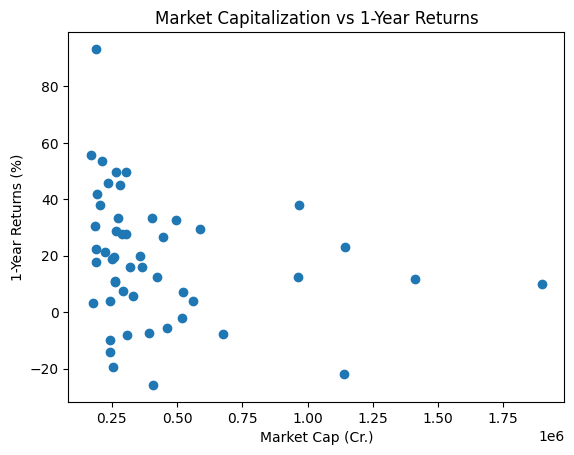

In [17]:
plt.scatter(df['Market Cap (Cr.)'], df['1 Yr Returns'])
plt.xlabel('Market Cap (Cr.)')
plt.ylabel('1-Year Returns (%)')
plt.title('Market Capitalization vs 1-Year Returns')
plt.show()

**Observation:**  
The relationship between market capitalization and returns appears weak, indicating that larger size does not necessarily imply higher or lower short-term performance within the large-cap universe.

## Technical Strength & Momentum

This section examines technical indicators to assess short-term momentum and relative strength among large-cap stocks.

### Relative Strength Index (RSI)

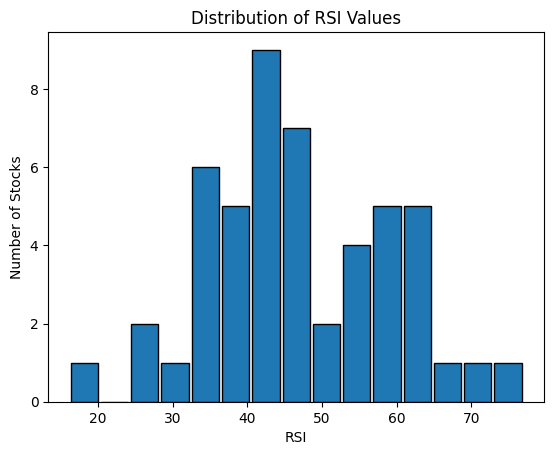

In [18]:
plt.hist(
    df['RSI'],
    bins=15,
    rwidth=0.9,
    edgecolor='black'
)
plt.xlabel('RSI')
plt.ylabel('Number of Stocks')
plt.title('Distribution of RSI Values')
plt.show()

**Observation:**  
Most large-cap stocks cluster around neutral RSI levels, indicating balanced momentum, with relatively few stocks exhibiting extreme overbought or oversold conditions.

### Moving Average Comparison (50 DMA vs 200 DMA)

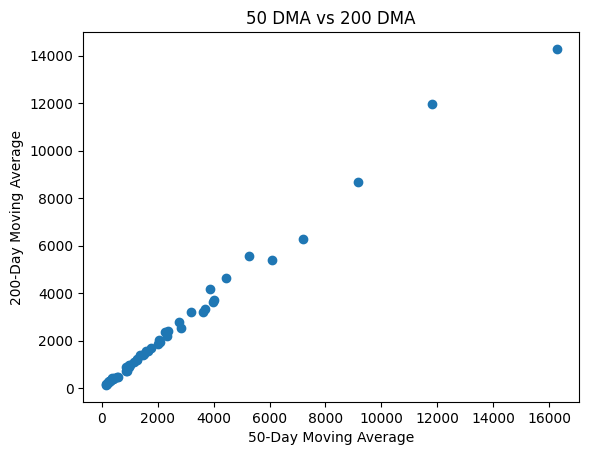

In [19]:
plt.scatter(df['50 DMA'], df['200 DMA'])
plt.xlabel('50-Day Moving Average')
plt.ylabel('200-Day Moving Average')
plt.title('50 DMA vs 200 DMA')
plt.show()

**Observation:**  
The comparison between short-term and long-term moving averages suggests that while several stocks exhibit positive momentum, a significant portion remain close to their long-term trends.

## Stock Screening & Segmentation

This section applies simple screening logic to group large-cap stocks based on performance, valuation, and market characteristics, highlighting how different stocks exhibit different profiles.

### Top Performing Stocks by 1-Year Returns

In [20]:
df[['Name', '1 Yr Returns', 'PE Ratio', 'Market Cap (Cr.)']] \
    .sort_values(by='1 Yr Returns', ascending=False) \
    .head(10)

,Name,1 Yr Returns,PE Ratio,Market Cap (Cr.)
46,Shriram Finance,93.25,18.81,189170.96
49,TVS Motors,55.77,61.50,169610.85
41,Hindalco Industries,53.58,11.88,212239.31
24,Bharat Electronics,49.57,51.67,305037.07
30,Vedanta,49.52,14.89,265378.49
39,Tata Steel,45.80,34.39,236063.50
27,Hindustan Zinc,44.96,24.96,282356.94
43,Eicher Motors,41.83,38.37,193353.53
4,State Bank of India,38.11,11.32,967691.79
42,SBI Life Insurance,37.87,84.04,202772.19


### Stocks with Strong Returns and Moderate Valuation

In [21]:
df[
    (df['1 Yr Returns'] > df['1 Yr Returns'].median()) &
    (df['PE Ratio'] < df['PE Ratio'].median())
][['Name', '1 Yr Returns', 'PE Ratio', 'Market Cap (Cr.)']] \
.sort_values(by='1 Yr Returns', ascending=False)

,Name,1 Yr Returns,PE Ratio,Market Cap (Cr.)
46,Shriram Finance,93.25,18.81,189170.96
41,Hindalco Industries,53.58,11.88,212239.31
30,Vedanta,49.52,14.89,265378.49
27,Hindustan Zinc,44.96,24.96,282356.94
4,State Bank of India,38.11,11.32,967691.79
16,Axis Bank,33.46,15.26,401969.17
28,Adani Power,33.26,22.60,271759.92
23,Adani Ports & SEZ,27.84,26.53,305486.85
2,Bharti Airtel,23.13,25.47,1141675.53
40,Indian Oil Corporation,21.34,8.79,224598.30


### High Valuation with Weaker Performance

In [22]:
df[
    (df['PE Ratio'] > df['PE Ratio'].median()) &
    (df['1 Yr Returns'] < df['1 Yr Returns'].median())
][['Name', '1 Yr Returns', 'PE Ratio', 'Market Cap (Cr.)']] \
.sort_values(by='PE Ratio', ascending=False)

,Name,1 Yr Returns,PE Ratio,Market Cap (Cr.)
36,Avenue Supermarts DMart,3.80,83.05,242339.50
8,Hindustan Unilever,3.84,50.91,561693.29
18,UltraTech Cement,15.90,49.37,364341.33
17,Sun Pharmaceutical,-7.29,36.90,392099.32
48,LTI Mindtree,3.28,36.67,176322.15
25,Hindustan Aeronautics,7.47,33.64,291131.13
31,Bajaj Auto,10.64,30.81,261664.38
12,HCL Technologies,-5.51,27.71,462164.30
38,Adani Enterprises,-9.74,27.18,240808.27
9,Larsen & Toubro,7.14,27.09,521867.87


## Key Insights & Findings

- Market capitalization among the top 50 Indian stocks is highly skewed, with a small number of companies accounting for a disproportionately large share of total market value. This highlights the dominance of a few market leaders even within the large-cap universe.

- One-year returns show significant dispersion across stocks, indicating that large-cap status alone does not guarantee uniform performance. Some stocks substantially outperform peers, while others deliver relatively muted returns.

- Valuation metrics, particularly the Price-to-Earnings (PE) ratio, are clustered within a moderate range for most stocks, with a small number of extreme outliers. These outliers can materially distort aggregate views of valuation if not handled carefully.

- The relationship between valuation (PE ratio) and short-term performance appears weak, suggesting that higher valuation does not consistently translate into superior one-year returns among large-cap stocks.

- Market capitalization does not exhibit a strong relationship with one-year returns, indicating that larger size does not necessarily imply either higher performance or downside protection in the short term.

- Technical indicators show that most stocks are positioned around neutral momentum levels, with relatively few exhibiting extreme overbought or oversold conditions, pointing to broadly balanced market sentiment.

## Limitations & Assumptions

- The analysis is based on a cross-sectional snapshot of data and does not incorporate time-series price movements. As a result, dynamic risk measures and performance consistency over time are not evaluated.

- The dataset focuses exclusively on the top 50 stocks by market capitalization, which may limit the generalizability of findings to mid-cap or small-cap stocks.

- Sectoral differences are not explicitly controlled for, and observed patterns may be influenced by industry-specific characteristics.

- Valuation and technical indicators are analysed independently and are not combined into a formal scoring or predictive model.

- The analysis is intended for exploratory and comparative purposes and does not constitute investment advice or definitive stock selection.

## Conclusion & Practical Implications

This exploratory data analysis highlights meaningful differences in performance, valuation, and technical characteristics among large-cap Indian stocks. Despite operating within the same market-cap category, stocks exhibit varied return profiles and valuation levels, underscoring the importance of multi-dimensional analysis in equity research.

The findings demonstrate how cross-sectional data can be effectively used for equity screening and comparative analysis, helping narrow down stocks that may warrant deeper fundamental or time-series investigation. From a practical standpoint, this framework is relevant for fintech analytics, equity research support, and preliminary portfolio screening, where the goal is to structure decision-making rather than generate direct investment recommendations.